In [2]:
import pandas as pd

soil = pd.read_parquet('../data/bronze/soil_readings')
print("Shape:", soil.shape)
print("\nColumns:", soil.columns.tolist())
print("\nSample:\n", soil.head(3))


Shape: (5002099, 12)

Columns: ['Local_Time', 'Site_Name', 'Site_ID', 'ID', 'Probe_ID', 'Probe_Measure', 'Soil_Value', 'Unit', 'json_featuretype', 'event_time', 'ingested_at', 'ingested_date']

Sample:
            Local_Time                    Site_Name Site_ID        ID Probe_ID  \
0 2025-04-09 17:00:00           Royal Parade CSIRO   88403  26868350  2031673   
1 2025-04-09 18:00:00  Kings Domain South fireyard   66199  26868390  1338696   
2 2025-04-09 14:00:00     Princess bridge East p06  101038  26868410  2019364   

           Probe_Measure  Soil_Value   Unit json_featuretype  \
0     Soil Salinity 20cm        0.51  µS/cm           Output   
1  Soil Salinity 60cm #0        1.02  µS/cm           Output   
2  Soil Temperature 20cm       16.42     ºC           Output   

           event_time                ingested_at ingested_date  
0 2025-04-09 17:00:00 2026-04-08 11:43:11.057522    2026-04-08  
1 2025-04-09 18:00:00 2026-04-08 11:43:11.057522    2026-04-08  
2 2025-04-09 14:00:0

In [3]:
print("Unique sites:", soil['Site_Name'].nunique())
print("\nSite names:\n", soil['Site_Name'].value_counts())



Unique sites: 73

Site names:
 Site_Name
Royal Parade CSIRO                                214784
Princess bridge East p06                          212700
Royal Parade Opposite Lawn 5                      204704
Royal Parade South                                204032
Princess bridge SE P01                            202700
                                                   ...  
Bourke North 6                                      1152
Southbank Bvd Playspace                               96
Queen Vic (could not locate)                          96
Kings Domain West (could not locate)                  64
Kings Domain South (could not locate) fireyard        64
Name: count, Length: 73, dtype: int64


In [4]:
print(soil['Probe_Measure'].value_counts())


Probe_Measure
Soil Moisture 10cm #0       122763
Soil Moisture 20cm #0       122762
Soil Moisture 30cm #0       122748
Soil Moisture 40cm #0       122748
Soil Temperature 10cm #0    122633
                             ...  
Soil Moisture 070cm              4
Soil Temperature 050cm           4
Soil Moisture 060cm              4
Soil Temperature 080cm           4
Soil Temperature 070cm           4
Name: count, Length: 170, dtype: int64


In [5]:
import re

# Extract just the measurement type (Moisture, Temperature, Salinity)
soil['measure_type'] = soil['Probe_Measure'].str.extract(r'(Moisture|Temperature|Salinity|Conductivity)')
print(soil['measure_type'].value_counts())


measure_type
Moisture       2470277
Temperature    1428922
Salinity       1102900
Name: count, dtype: int64


In [6]:
soil['event_time'] = pd.to_datetime(soil['event_time'], utc=True)
print("Date range:", soil['event_time'].min(), "->", soil['event_time'].max())
print("\nReadings per month:")
print(soil.set_index('event_time').resample('ME').size())



Date range: 2023-09-02 10:30:00+00:00 -> 2026-01-11 21:15:00+00:00

Readings per month:
event_time
2023-09-30 00:00:00+00:00    106784
2023-10-31 00:00:00+00:00    250479
2023-11-30 00:00:00+00:00    272026
2023-12-31 00:00:00+00:00    227598
2024-01-31 00:00:00+00:00    218989
2024-02-29 00:00:00+00:00    204781
2024-03-31 00:00:00+00:00    207932
2024-04-30 00:00:00+00:00    203470
2024-05-31 00:00:00+00:00    198413
2024-06-30 00:00:00+00:00    204997
2024-07-31 00:00:00+00:00    196309
2024-08-31 00:00:00+00:00    198764
2024-09-30 00:00:00+00:00    176371
2024-10-31 00:00:00+00:00    174579
2024-11-30 00:00:00+00:00    162408
2024-12-31 00:00:00+00:00    160215
2025-01-31 00:00:00+00:00    151726
2025-02-28 00:00:00+00:00    136600
2025-03-31 00:00:00+00:00    142032
2025-04-30 00:00:00+00:00    146260
2025-05-31 00:00:00+00:00    154808
2025-06-30 00:00:00+00:00    123475
2025-07-31 00:00:00+00:00     78029
2025-08-31 00:00:00+00:00    151290
2025-09-30 00:00:00+00:00    176056
2

In [7]:
moisture = soil[soil['measure_type'] == 'Moisture']
print(moisture['Soil_Value'].describe())
print("\nNull values:", moisture['Soil_Value'].isna().sum())
print("Zero values:", (moisture['Soil_Value'] == 0).sum())
print("Negative values:", (moisture['Soil_Value'] < 0).sum())
print("Above 100%:", (moisture['Soil_Value'] > 100).sum())


count    2.470205e+06
mean     3.307910e+01
std      1.468228e+01
min     -2.118000e+01
25%      2.335000e+01
50%      3.188000e+01
75%      4.049000e+01
max      1.081600e+02
Name: Soil_Value, dtype: float64

Null values: 72
Zero values: 100
Negative values: 9704
Above 100%: 550


In [8]:
salinity = soil[soil['measure_type'] == 'Salinity']
print(salinity['Soil_Value'].describe())
print("\nNegative values:", (salinity['Soil_Value'] < 0).sum())
print("Suspiciously high (>10 µS/cm):", (salinity['Soil_Value'] > 10).sum())


count    1.102864e+06
mean     2.952839e-01
std      2.784840e-01
min      0.000000e+00
25%      1.000000e-01
50%      2.200000e-01
75%      3.900000e-01
max      2.160000e+00
Name: Soil_Value, dtype: float64

Negative values: 0
Suspiciously high (>10 µS/cm): 0


In [9]:
# What depths do we have?
print(soil['Probe_Measure'].value_counts().head(30))



Probe_Measure
Soil Moisture 10cm #0       122763
Soil Moisture 20cm #0       122762
Soil Moisture 30cm #0       122748
Soil Moisture 40cm #0       122748
Soil Temperature 10cm #0    122633
Soil Temperature 20cm #0    122631
Soil Temperature 30cm #0    122615
Soil Temperature 40cm #0    122615
Soil Salinity 20cm #0       105014
Soil Salinity 10cm #0       105014
Soil Salinity 30cm #0       104998
Soil Moisture 60cm #0       100755
Soil Moisture 70cm #0       100755
Soil Moisture 50cm #0       100755
Soil Moisture 80cm #0       100754
Soil Temperature 60cm #0    100612
Soil Temperature 50cm #0    100612
Soil Temperature 70cm #0    100612
Soil Temperature 80cm #0    100612
Soil Salinity 40cm #0        83047
Soil Salinity 60cm #0        83036
Soil Salinity 80cm #0        83036
Soil Salinity 70cm #0        83036
Soil Salinity 50cm #0        83036
Soil Temperature 20cm        64465
Soil Temperature 40cm        64465
Soil Moisture 10cm           64465
Soil Moisture 20cm           64465
Soil M

In [10]:
# Extract depth from probe measure name
import re

def extract_depth(probe_measure):
    match = re.search(r'(\d+)\s*cm', str(probe_measure), re.IGNORECASE)
    return int(match.group(1)) if match else None

soil['depth_cm'] = soil['Probe_Measure'].apply(extract_depth)
print("Unique depths:", sorted(soil['depth_cm'].dropna().unique()))
print("\nRecords per depth:")
print(soil['depth_cm'].value_counts().sort_index())


Unique depths: [np.float64(10.0), np.float64(20.0), np.float64(30.0), np.float64(40.0), np.float64(50.0), np.float64(60.0), np.float64(70.0), np.float64(80.0)]

Records per depth:
depth_cm
10.0    755250
20.0    756178
30.0    756118
40.0    756116
50.0    450273
60.0    450273
70.0    450273
80.0    450270
Name: count, dtype: int64


In [11]:
# Are #0 probes and non-#0 probes at the same sites?
has_hash = soil[soil['Probe_Measure'].str.contains('#0')]['Site_Name'].unique()
no_hash = soil[~soil['Probe_Measure'].str.contains('#0')]['Site_Name'].unique()

print("Sites with #0 probes:", len(has_hash))
print("Sites without #0:", len(no_hash))
print("Overlap:", len(set(has_hash) & set(no_hash)))
print("\nSites with NO #0 (only plain):", set(no_hash) - set(has_hash))


Sites with #0 probes: 61
Sites without #0: 12
Overlap: 0

Sites with NO #0 (only plain): {'Bourke South 6 (297)', 'Block 2', 'Block 3', 'Princess bridge SE P01', 'Block 1', 'Southbank Bvd Playspace', 'Princess bridge NW p01', 'Princess bridge SW p10', 'Princess bridge NE p11', 'Royal Parade Opposite Lawn 5', 'Royal Parade CSIRO', 'Princess bridge East p06'}


In [13]:
has_hash = soil[soil['Probe_Measure'].str.contains('#0')]['Site_Name'].unique()
for s in sorted(has_hash)[:20]:
    print(s)


5th Fairway
8th Green
9th Fairway
Alexandra Gardens Engineers Lawn
Alexandra Gardens Star Lawn
Argyle Square
Bandstand
Batman Park
Bourke North 1
Bourke North 2
Bourke North 3
Bourke North 4
Bourke North 5
Bourke North 6
Bourke North 6 (280)
Bourke South 1
Bourke South 2
Bourke South 4
Bourke South 5
Carlton Gardens North


In [14]:
temp = soil[soil['measure_type'] == 'Temperature']
print(temp['Soil_Value'].describe())
print("\nNegative values:", (temp['Soil_Value'] < 0).sum())
print("Suspiciously high (>60°C):", (temp['Soil_Value'] > 60).sum())


count    1.428562e+06
mean    -2.825304e+02
std      1.703365e+03
min     -9.999000e+03
25%      1.240000e+01
50%      1.573000e+01
75%      1.908000e+01
max      3.822000e+01
Name: Soil_Value, dtype: float64

Negative values: 42594
Suspiciously high (>60°C): 0


In [15]:
coverage = soil.groupby('Site_Name')['measure_type'].nunique()
print("Sites with all 3 measure types:", (coverage == 3).sum())
print("Sites with only 2:", (coverage == 2).sum())
print("Sites with only 1:", (coverage == 1).sum())


Sites with all 3 measure types: 63
Sites with only 2: 10
Sites with only 1: 0


In [16]:
depth_coverage = soil.groupby('Site_Name')['depth_cm'].nunique()
print(depth_coverage.value_counts().sort_index())


depth_cm
4    22
8    51
Name: count, dtype: int64


In [17]:
print("Soil date range:", soil['event_time'].min(), "→", soil['event_time'].max())

import pandas as pd
rainfall = pd.read_parquet('../data/bronze/weather_rainfall')
print("Rainfall date range:", rainfall['date'].min(), "→", rainfall['date'].max())

solar = pd.read_parquet('../data/bronze/weather_solar')
print("Solar date range:", solar['date'].min(), "→", solar['date'].max())

temperature = pd.read_parquet('../data/bronze/weather_temperature')
print("Temperature date range:", temperature['date'].min(), "→", temperature['date'].max())


Soil date range: 2023-09-02 10:30:00+00:00 → 2026-01-11 21:15:00+00:00
Rainfall date range: 2013-01-01 → 2025-12-17
Solar date range: 1990-01-01 → 2025-12-16
Temperature date range: 2013-01-01 → 2025-12-16


In [18]:
missing = soil.groupby('Site_Name')['measure_type'].nunique()
missing_sites = missing[missing < 3].index.tolist()
print(soil[soil['Site_Name'].isin(missing_sites)].groupby(['Site_Name','measure_type']).size().unstack(fill_value=0))


measure_type             Moisture  Temperature
Site_Name                                     
Bandstand                   14560         7280
Batman Park                 42528        21424
Block 1                     15712        63899
Conservatory                27656        13832
Darling Square              51720        26240
Fawkner North               28296        14192
Natures Play                51080        25576
Southbank Bvd Playspace        64           32
Speakers Corner             14992         7496
Treasury West               50592        25304


In [19]:
# Pick one site, one measure, one depth — look at time between readings
sample = soil[
    (soil['Site_Name'] == 'Batman Park') & 
    (soil['measure_type'] == 'Moisture') &
    (soil['depth_cm'] == 10)
].sort_values('event_time')

print(sample['event_time'].diff().describe())
print("\nFirst 5 timestamps:")
print(sample['event_time'].head())


count                         5315
mean     0 days 03:37:18.570084666
std      1 days 14:28:01.998007116
min                0 days 00:00:00
25%                0 days 00:00:00
50%                0 days 00:03:15
75%                0 days 02:00:00
max              113 days 19:00:00
Name: event_time, dtype: object

First 5 timestamps:
2425307   2023-11-01 15:00:00+00:00
1130088   2023-11-01 15:00:00+00:00
2134297   2023-11-01 17:00:00+00:00
1054315   2023-11-01 17:00:00+00:00
3190171   2023-11-02 11:00:00+00:00
Name: event_time, dtype: datetime64[ns, UTC]


In [20]:
# Check if Site_ID or any column gives us location info
print(soil[['Site_Name', 'Site_ID']].drop_duplicates().head(20))


                           Site_Name Site_ID
0                 Royal Parade CSIRO   88403
1        Kings Domain South fireyard   66199
2           Princess bridge East p06  101038
3                        Batman Park   75504
5                 Royal Parade South   72758
6   Alexandra Gardens Engineers Lawn   66195
7             Princess bridge SE P01  101036
8                     H.G.Smith Oval   64985
9               Bourke South 6 (297)   88425
12          Fitzroy Gardens West '18   65011
13   Royal Parade University college   70829
16         Fitzroy Gardens South '18   65007
18                           Block 3  193880
35                        Ryder Oval   64987
43                 Kings Domain West   66198
45            Princess bridge NE p11  101037
57          Fitzroy Gardens East '18   64990
58                    Bourke North 1   65016
59                         Queen Vic   66204
68              Bourke North 6 (280)   66202


In [21]:
probe_suffixes = soil['Probe_Measure'].str.extract(r'#(\d+)')
print(soil[probe_suffixes[0].notna()]['Probe_Measure'].str.extract(r'#(\d+)')[0].value_counts())



0
0    3404071
4      50427
3      43192
5      42804
6      36484
7      21931
Name: count, dtype: int64


In [22]:
soil['Probe_Measure'].unique()[:50]


<ArrowStringArray>
[                 'Soil Salinity 20cm',               'Soil Salinity 60cm #0',
               'Soil Temperature 20cm',            'Soil Temperature 60cm #0',
                  'Soil Salinity 10cm',               '#0 Soil Moisture 20cm',
               '#0 Soil Moisture 30cm',               'Soil Temperature 40cm',
            'Soil Temperature 10cm #0',               'Soil Temperature 80cm',
                  'Soil Moisture 10cm',            'Soil Temperature 20cm #0',
               'Soil Moisture 60cm #0',               'Soil Salinity 40cm #0',
       'Soil Moisture (Adjusted) 70cm',                         'Temperature',
                  'Soil Moisture 20cm',               'Soil Temperature 70cm',
            'Soil Temperature 50cm #0',            'Soil Temperature 30cm #0',
                  'Soil Moisture 40cm',               'Soil Temperature 60cm',
               'Soil Moisture 10cm #0',            'Soil Temperature 70cm #0',
               '#0 Soil Moisture 

In [24]:
has_hash = soil[soil['Probe_Measure'].str.contains('#0')]['Site_Name'].unique()
for s in sorted(has_hash)[:20]:
    print(s)


5th Fairway
8th Green
9th Fairway
Alexandra Gardens Engineers Lawn
Alexandra Gardens Star Lawn
Argyle Square
Bandstand
Batman Park
Bourke North 1
Bourke North 2
Bourke North 3
Bourke North 4
Bourke North 5
Bourke North 6
Bourke North 6 (280)
Bourke South 1
Bourke South 2
Bourke South 4
Bourke South 5
Carlton Gardens North


In [25]:
soil['Probe_Measure'].str.extract(r'\((Clay.*?|Sandy.*?|Loam.*?)\)')[0].value_counts()


0
Clay           182438
Sandy Loam      84230
Clayey Loam     60434
Loam            16555
Name: count, dtype: int64

In [26]:
texture = soil['Probe_Measure'].str.extract(r'\((Clay.*?|Sandy.*?|Loam.*?)\)')[0]
soil['soil_texture'] = texture

# Does each site+depth have a consistent texture?
inconsistent = (
    soil[soil['soil_texture'].notna()]
    .groupby(['Site_Name', 'depth_cm'])['soil_texture']
    .nunique()
)
print("Sites+depths with >1 texture:", (inconsistent > 1).sum())
print("\nTexture per site+depth sample:")
print(soil[soil['soil_texture'].notna()].groupby(['Site_Name','depth_cm'])['soil_texture'].first().head(20))


Sites+depths with >1 texture: 0

Texture per site+depth sample:
Site_Name      depth_cm
5th Fairway    10.0         Sandy Loam
               20.0         Sandy Loam
               30.0         Sandy Loam
               40.0         Sandy Loam
8th Green      10.0         Sandy Loam
               20.0         Sandy Loam
               30.0               Clay
               40.0               Clay
9th Fairway    10.0         Sandy Loam
               20.0         Sandy Loam
               30.0         Sandy Loam
               40.0        Clayey Loam
Argyle Square  10.0         Sandy Loam
               20.0         Sandy Loam
               30.0         Sandy Loam
               40.0               Clay
               50.0               Clay
               60.0               Clay
               70.0               Clay
               80.0               Clay
Name: soil_texture, dtype: str


In [27]:
rainfall = pd.read_parquet('../data/bronze/weather_rainfall')
print(rainfall.shape)
print(rainfall.describe())
print("\nMissing rainfall_mm:", rainfall['rainfall_mm'].isna().sum())
print("Zero rainfall days:", (rainfall['rainfall_mm'] == 0).sum())


(4734, 10)
             year        month          day  rainfall_mm  period_days  \
count  4734.00000  4734.000000  4734.000000  4575.000000       4573.0   
mean   2018.98289     6.506971    15.703000     1.581552          1.0   
min    2013.00000     1.000000     1.000000     0.000000          1.0   
25%    2016.00000     4.000000     8.000000     0.000000          1.0   
50%    2019.00000     7.000000    16.000000     0.000000          1.0   
75%    2022.00000     9.000000    23.000000     0.800000          1.0   
max    2025.00000    12.000000    31.000000    54.600000          1.0   
std       3.73311     3.441193     8.798042     4.436133          0.0   

                         ingested_at  
count                           4734  
mean   2026-04-08 11:04:02.375960832  
min       2026-04-08 11:04:02.375961  
25%    2026-04-08 11:04:02.375961088  
50%    2026-04-08 11:04:02.375961088  
75%    2026-04-08 11:04:02.375961088  
max       2026-04-08 11:04:02.375961  
std                

In [28]:
solar = pd.read_parquet('../data/bronze/weather_solar')
print(solar.shape)
print(solar.describe())
print("\nMissing solar_exposure_mj:", solar['solar_exposure_mj'].isna().sum())


(13134, 8)
               year         month           day  solar_exposure_mj  \
count  13134.000000  13134.000000  13134.000000       12655.000000   
mean    2007.480356      6.516674     15.720192          15.027539   
min     1990.000000      1.000000      1.000000           0.100000   
25%     1998.000000      4.000000      8.000000           8.000000   
50%     2007.000000      7.000000     16.000000          12.900000   
75%     2016.000000     10.000000     23.000000          21.700000   
max     2025.000000     12.000000     31.000000          36.300000   
std       10.377730      3.445830      8.799797           8.588219   

                         ingested_at  
count                          13134  
mean   2026-04-08 11:04:58.849298944  
min       2026-04-08 11:04:58.849299  
25%    2026-04-08 11:04:58.849298944  
50%    2026-04-08 11:04:58.849298944  
75%    2026-04-08 11:04:58.849298944  
max       2026-04-08 11:04:58.849299  
std                              NaN  

Missin

In [29]:
temp_w = pd.read_parquet('../data/bronze/weather_temperature')
print(temp_w.shape)
print(temp_w.describe())
print("\nMissing max_temp_c:", temp_w['max_temp_c'].isna().sum())


(4733, 10)
              year        month          day   max_temp_c  days_accum  \
count  4733.000000  4733.000000  4733.000000  4579.000000      4579.0   
mean   2018.981618     6.505810    15.702726    20.330836         1.0   
min    2013.000000     1.000000     1.000000     9.000000         1.0   
25%    2016.000000     4.000000     8.000000    15.800000         1.0   
50%    2019.000000     7.000000    16.000000    19.100000         1.0   
75%    2022.000000     9.000000    23.000000    23.600000         1.0   
max    2025.000000    12.000000    31.000000    43.500000         1.0   
std       3.732480     3.440629     8.798951     6.019285         0.0   

                         ingested_at  
count                           4733  
mean   2026-04-08 11:04:31.622803456  
min       2026-04-08 11:04:31.622804  
25%    2026-04-08 11:04:31.622803968  
50%    2026-04-08 11:04:31.622803968  
75%    2026-04-08 11:04:31.622803968  
max       2026-04-08 11:04:31.622804  
std                

In [30]:
print("Date range:", rainfall['date'].min(), "→", rainfall['date'].max())
print("\nMissing dates (gaps)?")
full_range = pd.date_range(rainfall['date'].min(), rainfall['date'].max())
missing_dates = full_range.difference(pd.to_datetime(rainfall['date']))
print(f"{len(missing_dates)} missing dates")


Date range: 2013-01-01 → 2025-12-17

Missing dates (gaps)?
0 missing dates


In [31]:
print("Temp date range:", temp_w['date'].min(), "→", temp_w['date'].max())
full_range = pd.date_range(temp_w['date'].min(), temp_w['date'].max())
missing_dates = full_range.difference(pd.to_datetime(temp_w['date']))
print(f"Missing temp dates: {len(missing_dates)}")
print("Missing max_temp_c values:", temp_w['max_temp_c'].isna().sum())

print("\nSolar date range:", solar['date'].min(), "→", solar['date'].max())
full_range = pd.date_range(solar['date'].min(), solar['date'].max())
missing_dates = full_range.difference(pd.to_datetime(solar['date']))
print(f"Missing solar dates: {len(missing_dates)}")
print("Missing solar_exposure_mj values:", solar['solar_exposure_mj'].isna().sum())


Temp date range: 2013-01-01 → 2025-12-16
Missing temp dates: 0
Missing max_temp_c values: 154

Solar date range: 1990-01-01 → 2025-12-16
Missing solar dates: 0
Missing solar_exposure_mj values: 479


In [32]:
gold = pd.read_parquet('../data/gold/daily_site_summary')
print(gold.shape)
print(gold.columns.tolist())
print("\nIrrigation needed:", gold['irrigation_needed'].value_counts())
print("\nSample:")
gold[gold['irrigation_needed'] == True].head(3)


(33948, 34)
['date', 'site_name', 'site_id', 'moisture_10cm', 'moisture_20cm', 'moisture_30cm', 'moisture_40cm', 'moisture_50cm', 'moisture_60cm', 'moisture_70cm', 'moisture_80cm', 'temp_10cm', 'temp_20cm', 'temp_30cm', 'temp_40cm', 'temp_50cm', 'temp_60cm', 'temp_70cm', 'temp_80cm', 'salinity_10cm', 'salinity_20cm', 'salinity_30cm', 'salinity_40cm', 'salinity_50cm', 'salinity_60cm', 'salinity_70cm', 'salinity_80cm', 'avg_moisture_shallow', 'avg_moisture_deep', 'rainfall_mm', 'max_temp_c', 'solar_exposure_mj', 'irrigation_needed', 'transformed_at']

Irrigation needed: irrigation_needed
False    23266
True     10682
Name: count, dtype: int64

Sample:


,date,site_name,site_id,moisture_10cm,moisture_20cm,moisture_30cm,moisture_40cm,moisture_50cm,moisture_60cm,moisture_70cm,...,salinity_60cm,salinity_70cm,salinity_80cm,avg_moisture_shallow,avg_moisture_deep,rainfall_mm,max_temp_c,solar_exposure_mj,irrigation_needed,transformed_at
127,2026-01-07,9th Fairway,64976,28.94875,26.49875,25.12375,33.98750,NaN,NaN,NaN,...,NaN,NaN,NaN,28.639688,NaN,NaN,NaN,NaN,True,2026-04-09 01:31:45.628414
134,2023-11-01,Alexandra Gardens Engineers Lawn,66195,30.26625,31.18375,27.06000,26.06750,30.9875,35.52375,33.3300,...,0.2700,0.25,0.39,28.644375,35.568437,0.0,16.0,13.6,True,2026-04-09 01:31:45.628414
135,2023-11-03,Alexandra Gardens Engineers Lawn,66195,28.73000,30.31250,26.63625,25.86375,30.8400,35.25500,33.0575,...,0.2625,0.25,0.39,27.885625,35.206563,0.0,15.9,16.1,True,2026-04-09 01:31:45.628414


In [33]:
gold = pd.read_parquet('../data/gold/daily_site_summary')
print(gold.columns.tolist())
print("\nSoil texture values:")
print(gold['soil_texture'].value_counts())


['date', 'site_name', 'site_id', 'moisture_10cm', 'moisture_20cm', 'moisture_30cm', 'moisture_40cm', 'moisture_50cm', 'moisture_60cm', 'moisture_70cm', 'moisture_80cm', 'temp_10cm', 'temp_20cm', 'temp_30cm', 'temp_40cm', 'temp_50cm', 'temp_60cm', 'temp_70cm', 'temp_80cm', 'salinity_10cm', 'salinity_20cm', 'salinity_30cm', 'salinity_40cm', 'salinity_50cm', 'salinity_60cm', 'salinity_70cm', 'salinity_80cm', 'avg_moisture_shallow', 'avg_moisture_deep', 'soil_texture', 'rainfall_mm', 'max_temp_c', 'solar_exposure_mj', 'irrigation_needed', 'transformed_at']

Soil texture values:
soil_texture
Sandy Loam     5917
Clayey Loam    5665
Name: count, dtype: int64


In [34]:
gold_hourly = pd.read_parquet('../data/gold/hourly_site_summary')
print(gold_hourly.shape)
print(gold_hourly.columns.tolist())
print(gold_hourly.head(2))


(162747, 31)
['site_name', 'site_id', 'hour', 'moisture_10cm', 'moisture_20cm', 'moisture_30cm', 'moisture_40cm', 'moisture_50cm', 'moisture_60cm', 'moisture_70cm', 'moisture_80cm', 'temp_10cm', 'temp_20cm', 'temp_30cm', 'temp_40cm', 'temp_50cm', 'temp_60cm', 'temp_70cm', 'temp_80cm', 'salinity_10cm', 'salinity_20cm', 'salinity_30cm', 'salinity_40cm', 'salinity_50cm', 'salinity_60cm', 'salinity_70cm', 'salinity_80cm', 'avg_moisture_shallow', 'avg_moisture_deep', 'soil_texture', 'transformed_at']
     site_name site_id                hour  moisture_10cm  moisture_20cm  \
0  5th Fairway   64971 2023-09-03 16:00:00          38.16         32.905   
1  5th Fairway   64971 2023-09-04 18:00:00          38.11         32.690   

   moisture_30cm  moisture_40cm  moisture_50cm  moisture_60cm  moisture_70cm  \
0         33.760         30.260            NaN            NaN            NaN   
1         33.625         30.255            NaN            NaN            NaN   

   ...  salinity_30cm  salini

In [35]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Pick one site with good data
site = gold[gold['site_name'] == 'Alexandra Gardens Engineers Lawn'].sort_values('date')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Moisture
ax1.plot(site['date'], site['avg_moisture_shallow'], color='brown', label='Avg Moisture Shallow')
ax1.axhline(30, color='red', linestyle='--', linewidth=0.8, label='Irrigation threshold (30%)')
ax1.set_ylabel('Soil Moisture (%)')
ax1.legend()
ax1.set_title('Alexandra Gardens — Soil Moisture vs Rainfall')

# Rainfall as bar chart
ax2.bar(site['date'], site['rainfall_mm'], color='steelblue', label='Rainfall (mm)', width=1)
ax2.set_ylabel('Rainfall (mm)')
ax2.set_xlabel('Date')
ax2.legend()

plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'matplotlib'

In [36]:
pip install matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 551.2 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 1.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 11.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 3.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 12.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 9.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 13.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 3.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


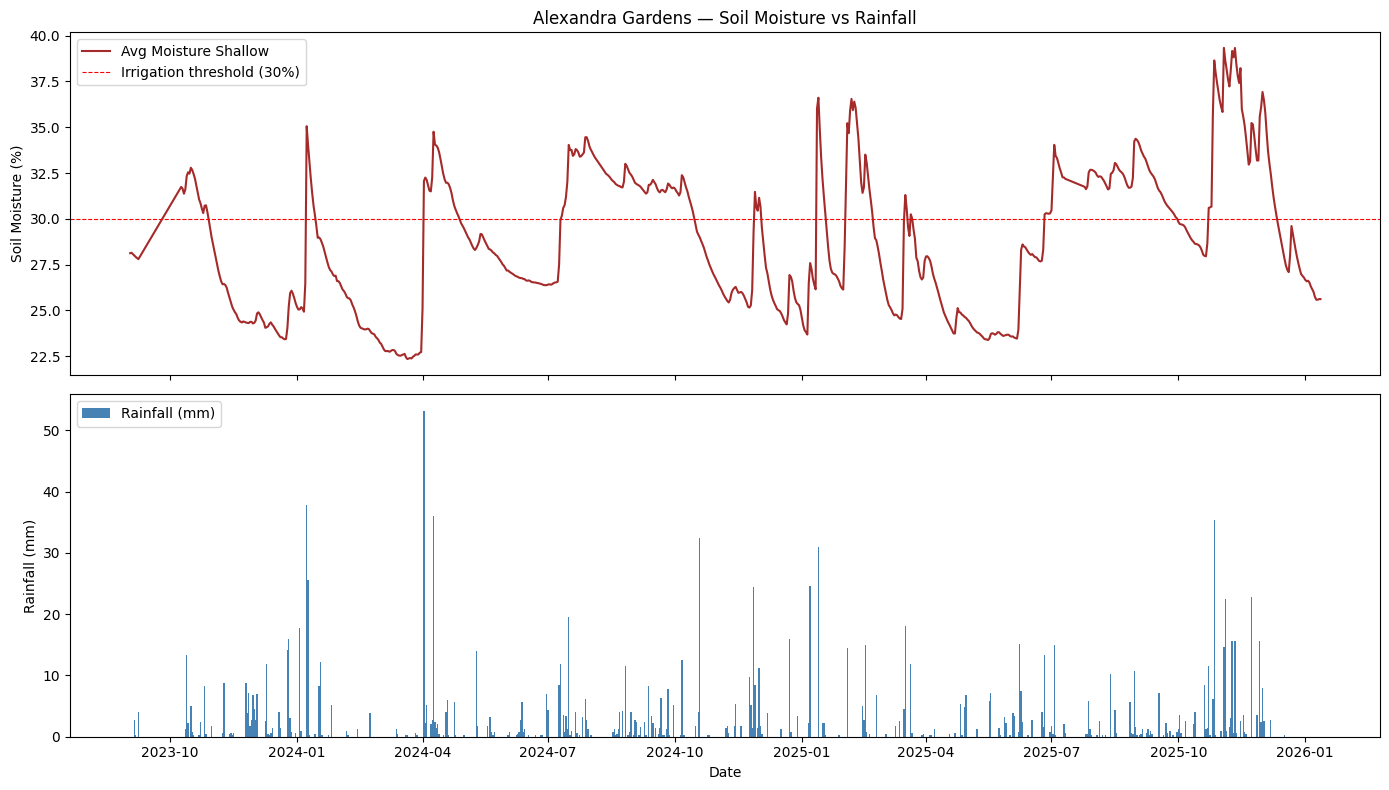

In [37]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Pick one site with good data
site = gold[gold['site_name'] == 'Alexandra Gardens Engineers Lawn'].sort_values('date')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Moisture
ax1.plot(site['date'], site['avg_moisture_shallow'], color='brown', label='Avg Moisture Shallow')
ax1.axhline(30, color='red', linestyle='--', linewidth=0.8, label='Irrigation threshold (30%)')
ax1.set_ylabel('Soil Moisture (%)')
ax1.legend()
ax1.set_title('Alexandra Gardens — Soil Moisture vs Rainfall')

# Rainfall as bar chart
ax2.bar(site['date'], site['rainfall_mm'], color='steelblue', label='Rainfall (mm)', width=1)
ax2.set_ylabel('Rainfall (mm)')
ax2.set_xlabel('Date')
ax2.legend()

plt.tight_layout()
plt.show()


In [38]:
# Rainfall vs next-day moisture change
site = gold[gold['site_name'] == 'Alexandra Gardens Engineers Lawn'].sort_values('date').copy()

site['moisture_change'] = site['avg_moisture_shallow'].diff()
site['prev_rainfall'] = site['rainfall_mm'].shift(1)

# Show days after significant rainfall
print(site[site['prev_rainfall'] > 5][['date', 'prev_rainfall', 'avg_moisture_shallow', 'moisture_change']].head(20))


             date  prev_rainfall  avg_moisture_shallow  moisture_change
25634  2023-10-14           13.4             32.538125         0.211250
25639  2023-10-27            8.2             30.738438         0.022813
138    2023-11-10            8.8             26.390313        -0.055000
8644   2023-11-26            8.8             24.323750        -0.020937
144    2023-11-28            7.2             24.383437         0.071563
17113  2023-12-01            6.8             24.323438         0.033438
17114  2023-12-04            7.0             24.901250         0.065625
148    2023-12-11           11.8             24.134062         0.050625
17120  2023-12-26           14.2             25.220625         1.186875
17121  2023-12-27           16.0             25.951250         0.730625
25650  2024-01-04           17.8             25.184062         0.122187
8658   2024-01-09           37.8             34.024375        -1.031562
153    2024-01-10           25.6             33.087812        -0

In [39]:
print(site[site['irrigation_needed'] == True][['date', 'avg_moisture_shallow', 'rainfall_mm']].head(10))
print("\nTotal irrigation days for this site:", site['irrigation_needed'].sum())


             date  avg_moisture_shallow  rainfall_mm
25626  2023-09-02             28.125000          0.0
25627  2023-09-03             28.148125          0.0
25628  2023-09-04             28.076562          0.0
25629  2023-09-06             27.922812          0.2
25630  2023-09-07             27.860000          0.0
17107  2023-10-29             29.941250          0.0
8636   2023-10-30             29.472812          0.0
25640  2023-10-31             29.019063          1.8
134    2023-11-01             28.644375          0.0
8637   2023-11-02             28.290937          0.0

Total irrigation days for this site: 436
